###**RideNow Platform: Customer Behavior & Service Bundling**

###**Business Context**

As a Product Manager at RideNow, a multi-service mobility platform offering ride
options (Economy, Premium, Shared), add-on services (e.g., Extra Luggage), adjacent
services (Food Delivery, Grocery), and a subscription plan (RidePass). The firm wants to
understand how customers combine services within a session to improve cross-service
usage, design bundles, and increase retention.

###**Dataset Description**
Each row represents a single user session. Columns are binary (1 = used, 0 = not used).

* EconomyRide, PremiumRide, SharedRide: ride types
* FoodDelivery, Grocery: adjacent services
* RidePass: subscription indicator
* AirportRide: airport-related trips
* LateNight: usage between ~10pm–5am
* ExtraLuggage: add-on service

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

import numpy as np
import pandas as pd
%matplotlib inline

from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules
import matplotlib.pylab as plt


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [3]:
data = pd.read_csv("/content/drive/MyDrive/BUSA-710 Prof.Mittal/uber_arm_dataset-1.csv")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [4]:
data.head()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,EconomyRide,PremiumRide,SharedRide,FoodDelivery,Grocery,RidePass,AirportRide,LateNight,ExtraLuggage
0,1,0,0,1,0,1,0,1,0
1,0,1,0,1,1,0,1,0,1
2,0,0,0,0,0,0,0,0,1
3,0,0,1,0,0,0,0,0,0
4,0,0,0,1,0,0,0,1,0


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

EconomyRide     0.2604
PremiumRide     0.4494
SharedRide      0.2464
FoodDelivery    0.3784
Grocery         0.2578
RidePass        0.2494
AirportRide     0.2524
LateNight       0.2478
ExtraLuggage    0.3692
dtype: float64


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

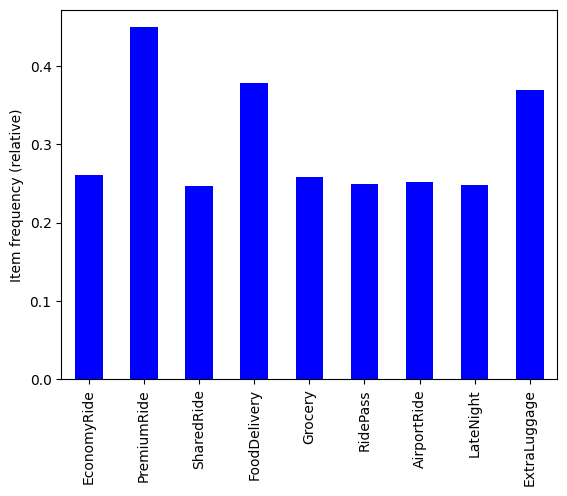

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [5]:
itemFrequency = data.sum(axis=0) / len(data)
print(itemFrequency)

# and plot as histogram
ax = itemFrequency.plot.bar(color="blue")
plt.ylabel("Item frequency (relative)")
plt.show()

In [6]:
# Item / division frequency (share of transactions)
freq = data.mean().sort_values(ascending=False)
freq

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,0
PremiumRide,0.4494
FoodDelivery,0.3784
ExtraLuggage,0.3692
EconomyRide,0.2604
Grocery,0.2578
AirportRide,0.2524
RidePass,0.2494
LateNight,0.2478
SharedRide,0.2464


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


###Most Frequently Used Services:

* PremiumRide is the most popular service, used in about 45% of sessions.
* FoodDelivery comes in second, used in about 38% of sessions.
* ExtraLuggage is close behind, used in about 37% of sessions.
###Overall Usage Patterns:

* PremiumRide, FoodDelivery, and ExtraLuggage are clearly the top three services that customers engage with on the RideNow platform. This suggests that customers frequently opt for premium ride experiences, convenience foods, and additional luggage capacity.
* The other services like EconomyRide, Grocery, AirportRide, RidePass, LateNight, and SharedRide are used with similar, but lower, frequencies, all hovering around 25% to 26% of sessions. This indicates a consistent, but less dominant, demand for these services compared to the top three.
* This data highlights that while core ride services are important, convenience (FoodDelivery) and added comfort/utility (ExtraLuggage) are also significant drivers of customer engagement. The relatively even distribution among the lower-frequency services suggests a diverse set of needs being met, but none stand out as strongly as the top performers.

the service usage patterns tell us, and some action plans:

### Business Interpretation: What's Happening?
* The 'Premium Convenience' Craze: Your customers absolutely love PremiumRide, but they also highly value FoodDelivery and ExtraLuggage. This isn't just about getting from A to B; it's about making their lives easier and more comfortable. They're willing to pay for a better experience and extra utility right alongside their rides.

* Diverse, but Under-tapped, Needs: While the top three services shine, a solid chunk of your customers use other services like EconomyRide, Grocery, AirportRide, LateNight, and RidePass. These services meet various, albeit less frequent, needs. There's potential here, but they're not currently driving the same level of engagement as your stars.

* Opportunity for Deeper Engagement: The strong performance of the top services creates a perfect springboard to introduce customers to other offerings and build stronger loyalty.

 **Consultant Action Plan: What Should RideNow Do?**

As your consultant, I recommend focusing on these key areas:

Strategic Bundling – The 'Power Trio' Package:

* Create irresistible bundles that combine PremiumRide with FoodDelivery or ExtraLuggage. Think: a "Seamless Commute" package (PremiumRide + Coffee Delivery) or a "Traveler's Ease" package (PremiumRide to Airport + Extra Luggage).
* Offer these bundles upfront during the booking process for Premium Rides. Make it a natural add-on that saves them money or time.
**Boost 'Mid-Tier' Services Through Smart Cross-Promotion:**

* Contextual Nudges: If a user frequently orders FoodDelivery, subtly suggest Grocery delivery next time. If they're booking an AirportRide, offer a discounted ExtraLuggage add-on.
* Identify Usage Occasions: For LateNight rides, perhaps a special bundle with a late-night food delivery option. For SharedRide, could it be bundled with a specific value-oriented food option?
**Enhance RidePass Value for Retention:**

* Exclusive Bundles: Analyze what your RidePass subscribers are already using. Then, create exclusive bundles or discounts on other services only for RidePass members. This makes the subscription more valuable and encourages them to explore more of the platform.
* Highlight Savings: Clearly communicate how much RidePass members save when they use other services alongside their subscription.
In essence: Leverage your most popular services to introduce and grow engagement with your other offerings. Make convenience and value the core of your bundling strategy to encourage customers to use more services within a single session and, ultimately, stay with RideNow longer

## 4. Think Before You Run Apriori
Write 1–2 hypotheses (predictions) **before** generating rules.
#####**Hypothesis 1**
(RidePass Cross-Service Engagement): Users with an active RidePass subscription are more likely to combine their rides with other adjacent services like FoodDelivery or Grocery compared to non-subscribers. This would indicate RidePass successfully drives broader platform engagement.

#####**Hypothesis 2**
(Late Night Service Needs): LateNight sessions will frequently show an association with PremiumRide (for perceived safety/comfort) or FoodDelivery (for late-night cravings). This could point to specific bundling opportunities during off-peak hours.
#####**Hypothesis 3**
(Airport-Specific Bundling): AirportRide sessions will have a strong association with ExtraLuggage and potentially PremiumRide, reflecting travelers' needs for additional utility and comfort during airport transfers.

In [7]:
min_support = 0.1  # adjust if needed
itemsets = apriori(data, min_support=min_support, use_colnames=True)
itemsets.sort_values('support', ascending=False)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,support,itemsets
1,0.4494,(PremiumRide)
3,0.3784,(FoodDelivery)
8,0.3692,(ExtraLuggage)
0,0.2604,(EconomyRide)
4,0.2578,(Grocery)
6,0.2524,(AirportRide)
15,0.2524,"(AirportRide, PremiumRide)"
5,0.2494,(RidePass)
7,0.2478,(LateNight)
2,0.2464,(SharedRide)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


The support threshold of 10% (0.1). This threshold was chosen as a balanced starting point, low enough to capture meaningful multi-item associations but not so low as to generate an unmanageable number of rules. Even the least frequent single item(Such as Latenight, SharedRide, RidePass) has a support of around 24.6%, so support of
0.1 allows for combinations of these items to be identified effectively for business actions like bundling.

In [8]:
min_conf = 0.4  # adjust if needed
rules = association_rules(itemsets, metric='confidence', min_threshold=min_conf)
rules = rules[['antecedents', 'consequents', 'support', 'confidence', 'lift', 'conviction']]
print(f"Number of rules {len(rules)}")
rules.head(20)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Number of rules 19


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,antecedents,consequents,support,confidence,lift,conviction
0,(EconomyRide),(PremiumRide),0.1168,0.448541,0.998088,0.998442
1,(SharedRide),(PremiumRide),0.1048,0.425325,0.946428,0.958106
2,(FoodDelivery),(PremiumRide),0.1696,0.448203,0.997336,0.997831
3,(Grocery),(PremiumRide),0.1120,0.434445,0.966723,0.973557
4,(RidePass),(PremiumRide),0.1154,0.462711,1.029618,1.024773
5,(AirportRide),(PremiumRide),0.2524,1.000000,2.225189,inf
6,(PremiumRide),(AirportRide),0.2524,0.561638,2.225189,1.705439
7,(LateNight),(PremiumRide),0.1056,0.426150,0.948265,0.959484
8,(ExtraLuggage),(PremiumRide),0.2290,0.620260,1.380196,1.449940
9,(PremiumRide),(ExtraLuggage),0.2290,0.509568,1.380196,1.286214


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [9]:
# sort by confidence level
rules = rules.sort_values("confidence", ascending=False)
rules

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,antecedents,consequents,support,confidence,lift,conviction
5,(AirportRide),(PremiumRide),0.2524,1.000000,2.225189,inf
14,"(AirportRide, ExtraLuggage)",(PremiumRide),0.1786,1.000000,2.225189,inf
16,"(ExtraLuggage, PremiumRide)",(AirportRide),0.1786,0.779913,3.089987,3.396833
10,(RidePass),(FoodDelivery),0.1928,0.773055,2.042958,2.738994
12,(AirportRide),(ExtraLuggage),0.1786,0.707607,1.916595,2.157370
17,(AirportRide),"(ExtraLuggage, PremiumRide)",0.1786,0.707607,3.089987,2.636862
15,"(AirportRide, PremiumRide)",(ExtraLuggage),0.1786,0.707607,1.916595,2.157370
8,(ExtraLuggage),(PremiumRide),0.2290,0.620260,1.380196,1.449940
6,(PremiumRide),(AirportRide),0.2524,0.561638,2.225189,1.705439
9,(PremiumRide),(ExtraLuggage),0.2290,0.509568,1.380196,1.286214


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Choosing a confidence threshold of 0.4 (40%) is a strategic move to uncover more 'hidden' relationships. Here is how we justify it:

* Capturing Niche Services: Several of our services, like LateNight, RidePass, and SharedRide, only appear in about 24-25% of all sessions. If we kept the threshold at 50% or higher, we might miss how these specific groups behave. A 40% threshold allows us to see patterns for these smaller but high-potential segments.

* Broadening the Discovery Funnel: At 40%, we are saying: 'If a customer does A, there is a significant 40% chance they will do B.' While not a majority, this is still 4x higher than random chance and provides enough signal to test marketing promotions or UI placements.

* Identifying Emerging Bundles: Lowering the bar slightly helps us find 'weak ties'—combinations that aren't yet habits for the majority but are becoming trends among our most active users. It gives the Product team more 'raw material' to work with when designing new experiments.

# Let us interpret the rules in simple language

In [10]:
# Sort by lift, interpret and decide
rules = rules.sort_values("lift", ascending=False)
rules

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,antecedents,consequents,support,confidence,lift,conviction
16,"(ExtraLuggage, PremiumRide)",(AirportRide),0.1786,0.779913,3.089987,3.396833
17,(AirportRide),"(ExtraLuggage, PremiumRide)",0.1786,0.707607,3.089987,2.636862
5,(AirportRide),(PremiumRide),0.2524,1.000000,2.225189,inf
14,"(AirportRide, ExtraLuggage)",(PremiumRide),0.1786,1.000000,2.225189,inf
6,(PremiumRide),(AirportRide),0.2524,0.561638,2.225189,1.705439
11,(FoodDelivery),(RidePass),0.1928,0.509514,2.042958,1.530318
10,(RidePass),(FoodDelivery),0.1928,0.773055,2.042958,2.738994
15,"(AirportRide, PremiumRide)",(ExtraLuggage),0.1786,0.707607,1.916595,2.157370
12,(AirportRide),(ExtraLuggage),0.1786,0.707607,1.916595,2.157370
13,(ExtraLuggage),(AirportRide),0.1786,0.483749,1.916595,1.448132


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


### **Detailed Interpretation of Key Rules**

| Rule | Behavioral Narrative | Context/Incentive | Actionable? |
| :--- | :--- | :--- | :--- |
| Rule 12 **Airport → ExtraLuggage** | High-utility travel. | Need for space and reliability for flights. | **YES**: Pre-select add-ons for airport routes. |
| Rule 10 **RidePass → FoodDelivery** | Ecosystem loyalty. | Maximizing subscription value and convenience. | **YES**: Market 'Free Delivery' for RidePass. |
| Rule 7 **LateNight → PremiumRide** | Prioritizing safety/comfort. | Willingness to pay more for security during off-hours. | **YES**: Emphasize safety features in late-night UI. |

I have selected three key rules that represent different segments of your customers. I'll explain the behavior behind the numbers and whether they are worth your investment as a Product Manager.

1. The 'Traveler' Bundle: (AirportRide) → (ExtraLuggage)
What exactly is happening? Customers heading to the airport are frequently selecting the extra luggage add-on. This isn't just a random choice; it represents the heavy-packer or international traveler segment.
Why might users behave this way? Airport trips are high-stakes. Travelers likely have checked bags and want to ensure their vehicle can accommodate them. They are in a 'utility-first' mindset and are willing to pay for the peace of mind that their bags will fit.
Would you act on this? Yes. This is a prime opportunity for a 'Traveler's Ease' bundle. You could offer a pre-selected package that includes both the ride and luggage handling at a slight discount, or simply prompt the user with a 'Don't forget your luggage space' notification during the airport booking flow.
2. The 'Subscriber Habit': (RidePass) → (FoodDelivery)
What exactly is happening? Users who have committed to a monthly subscription are heavily using the platform for food, not just rides. They are treating RideNow as an all-in-one lifestyle app.
Why might users behave this way? Once a user pays for RidePass, they feel an 'incentive to utilize.' They want to maximize the value of their subscription. If the subscription offers reduced delivery fees or exclusive access to certain restaurants, it becomes their default choice for cravings.
Would you act on this? Yes. You should double down on this. Use this data to negotiate better exclusive deals with food partners for RidePass members. It increases the 'stickiness' of the subscription and prevents them from switching to a dedicated food delivery competitor.
3. The 'Safety & Comfort' Choice: (LateNight) → (PremiumRide)
What exactly is happening? Users traveling late at night (10pm–5am) are opting for the higher-tier Premium vehicles rather than the cheaper Economy or Shared options.
Why might users behave this way? Late at night, the primary driver of behavior is often perceived safety and reliability. Customers want a high-rated driver and a clean, reliable car when they are tired or in a potentially less secure environment. The price sensitivity drops in favor of comfort and security.

Would you act on this? Yes, but carefully. Instead of a discount (which isn't needed here), focus on marketing. we can highlight the 'Safety Features' of Premium rides during late hours. we might also consider a 'NightOwl' loyalty program where frequent late-night premium users get priority dispatch.



### **Critical Analysis: LateNight vs. RidePass**

| Metric | LateNight → Premium | RidePass → FoodDelivery | Business Implication |
| :--- | :--- | :--- | :--- |
| **Lift** | ~0.95 (Low) | ~2.04 (High) | RidePass *causes* food orders; LateNight is just a coincidence. |
| **Confidence** | 42% | 77% | RidePass is a much more reliable predictor. |
| **Action** | **Monitor/Protect** | **Aggressive Expansion** | Focus budget where the 'Lift' is highest. |

 From a purely statistical standpoint, the LateNight → PremiumRide rule is weaker than the others. Here is how to interpret that 'lack of sense' from a Product Manager's perspective:

Low Frequency (Support): Since only ~25% of sessions are LateNight, and even fewer are LateNight + Premium, this is a 'niche' behavior. It won't move the needle on your total quarterly revenue as much as Airport or FoodDelivery rules will.

Low Lift (~0.95): This is the most important part. A lift near 1.0 means that people who ride late at night are no more likely to choose Premium than any other random customer. In other words, being 'LateNight' doesn't trigger the desire for Premium; those users might just be Premium riders regardless of the time.

Does it make sense?

Pure Cross-Selling (No): It does not make sense to spend a marketing budget trying to 'convert' LateNight users to Premium, because the lift shows there isn't a special connection there.
Operational Safety (Yes): Even if the lift is low, the Confidence (~42%) tells us that nearly half of your late-night revenue comes from Premium. From a business 'insurance' perspective, We act on this not to grow sales, but to protect your most valuable late-night customers by ensuring Premium cars are positioned in nightlife areas.


###9. Decision Layer (Most Important)

### **Executive Summary: Strategic Recommendations for RideNow**

| Strategic Pillar | Actionable Initiative | Primary Goal |
| :--- | :--- | :--- |
| **High-Value Travel** | **Airport Automation**: One-tap 'Extra Luggage' prompts for all airport-bound Premium rides. | Increase Average Order Value (AOV) |
| **Subscription Growth** | **RidePass Ecosystem**: Bundle food delivery perks directly into the RidePass subscription tier. | Increase Customer Lifetime Value (CLV) |


### **Proposed Business Actions**

#### **1. The 'Traveler’s Ease' Dynamic Prompt**
*   **Rule used:** `(AirportRide) → (ExtraLuggage)` (Confidence: 0.71, Lift: 1.92)
*   **Action:** Implement a **Dynamic Add-on Modal** in the booking flow. When a user selects 'Airport' as their destination, the app will automatically trigger a pop-up: *"Bringing bags? Add 'Extra Luggage' space to your Premium Ride for just $X more."* with a one-tap 'Add to Trip' button.
*   **Target users:** Any user whose destination is tagged as an Airport.
*   **Expected impact:** Increase in average order value (AOV) for airport trips and a reduction in driver-passenger friction regarding luggage capacity.
*   **Why this rule?** It has high confidence (71%) and high lift (nearly 2x), meaning the need for luggage is specifically tied to the airport context.

#### **2. The 'Ecosystem Lock-in' Food Benefit**
*   **Rule used:** `(RidePass) → (FoodDelivery)` (Confidence: 0.77, Lift: 2.04)
*   **Action:** Launch a **'RidePass+ Bites' Campaign**. Every RidePass subscriber receives 3 'Zero-Fee' delivery vouchers per month. Additionally, push a notification to new RidePass sign-ups: *"Your subscription now covers your dinner too. Enjoy $0 delivery on your first 3 food orders this month."*
*   **Target users:** Current RidePass subscribers who have not used FoodDelivery in the last 30 days.
*   **Expected impact:** Increase in month-over-month subscription retention and a boost in cross-service revenue from the food division.
*   **Why this rule?** This is our strongest rule by Lift (2.04). It proves that the subscription is a powerful driver of ecosystem loyalty, making it the most reliable predictor of cross-service expansion.

###10. Critical Thinking — Reject a Rule



| Rejected Rule | Confidence | Lift | Business Reason for Rejection |
| :--- | :--- | :--- | :--- |
| **(AirportRide) → (PremiumRide)** | **1.0 (100%)** | 2.23 | **Saturation**: Behavior is already universal. No room for incremental growth or cross-selling. |

I have identified Rule 5: (AirportRide) → (PremiumRide) as the primary candidate to reject. While its metrics are perfect, it is a 'false signal'
#####The Rule 5:
* Antecedent: (AirportRide)
* Consequent: (PremiumRide)
* Confidence: 1.0 (100%)
* Lift: ~2.23

Why it's not actionable:
* Redundancy: A confidence of 1.0 means that every single time a customer booked an AirportRide, they also booked a PremiumRide. This suggests that on the RideNow platform, AirportRides might already be restricted to the 'Premium' tier by default, or the user base for airport travel is exclusively high-end.
* No Growth Opportunity: We cannot 'encourage' a behavior that is already happening 100% of the time. Since there are no Economy or Shared rides occurring for the airport in this dataset, there is no 'segment' of users to convert to Premium.
* Resource Waste: If we spent budget promoting 'Premium Rides' to people already booking them for the airport, we would be 'cannibalizing' your own marketing spend with zero incremental revenue.

## 11. Final Reflection (Lift vs Confidence)

If you had to choose between:
- a **high-confidence** rule, and
- a **high-lift** rule,

which would you trust more **in this dataset** and why?




*   **The Problem with Confidence:** In this dataset, high confidence often points to 'System Constraints' (e.g., Airport is always Premium). Acting on these results in zero incremental revenue.
*   **The Power of Lift:** High Lift identifies **Cross-Service Catalysts**. For example, the Lift of 2.04 for `RidePass → FoodDelivery` shows that a RidePass makes a user **twice as likely** to order food compared to a normal user. This is a clear signal for a Product Manager to invest in that specific bridge.
*   **Conclusion:** Trust **Lift** for *Growth and Cross-Selling* strategies; trust **Confidence** only for *Operational Planning* and protecting existing revenue.

In this specific RideNow dataset, I would trust a high-lift rule more than a high-confidence rule for making product decisions.

Here is why:

Lift Reveals 'The Nudge': Confidence only tells us how often B happens when A happens. However, as we saw with (AirportRide) → (PremiumRide), high confidence can be a 'false friend' that simply reflects a system rule or a habit that is already 100% saturated. Lift, on the other hand, tells us how much the presence of A increases the likelihood of B. A high lift (like 2.04 for RidePass → FoodDelivery) proves that the subscription is actually changing customer behavior.

Avoiding Redundancy: Many high-confidence rules in mobility data are 'logical tautologies' (e.g., if you are at an airport, you have luggage). Trusting high-lift rules helps you find non-obvious connections that represent actual growth opportunities.

Reliability in Sparse Data: Because many of our niche services (SharedRide, LateNight) have lower baseline frequencies, confidence scores can be misleadingly low. Lift adjusts for these baselines, allowing us to find strong relative patterns even in smaller segments of our user base.